# IC Inference: HAC Adjustment and Block Bootstrap

**Docker image**: `ml4t`

**Chapter 7: Defining the Learning Task**
**Section Reference**: 7.3 - Feature and Label Evaluation as Triage

## Purpose

This notebook addresses **statistical inference for IC**: how confident should we
be that a signal's IC is not just noise? We cover HAC adjustment for autocorrelated
IC series and block bootstrap for robust confidence intervals.

## Learning Objectives

1. Understand why naive t-statistics fail for IC inference
2. Apply HAC (Newey-West) adjustment for proper standard errors
3. Implement block bootstrap for distribution-free confidence intervals
4. Distinguish practical vs statistical significance
5. Plan track records using HAC-adjusted effective sample size

## Data Policy

Examples use **real ETF data** from the case study store.

## Prerequisites

- `05_signal_evaluation` — produces the IC time series whose inference we
  formalize here.
- Familiarity with autocorrelation, the Newey-West HAC estimator, and
  block bootstrap.

In [1]:
"""IC Inference — statistical testing and confidence intervals for information coefficients."""

from __future__ import annotations

import json
import logging
import warnings

import numpy as np
import plotly.graph_objects as go
import polars as pl
from arch.bootstrap import StationaryBootstrap
from IPython.display import display
from ml4t.diagnostic.evaluation.autocorrelation import analyze_autocorrelation
from ml4t.diagnostic.metrics import compute_ic_hac_stats
from ml4t.diagnostic.signal import analyze_signal
from plotly.subplots import make_subplots
from scipy import stats

from data import load_etfs
from utils.reproducibility import set_global_seeds
from utils.style import COLORS  # importing utils.style activates the ml4t Plotly template

warnings.filterwarnings("ignore")
# Quiet ml4t library INFO logging. Child loggers (e.g. ml4t.diagnostic.evaluation.
# autocorrelation) set their own level, so raising the parent alone does not silence
# them - set every already-created ml4t logger explicitly.
for _lg in list(logging.root.manager.loggerDict):
    if _lg.startswith("ml4t"):
        logging.getLogger(_lg).setLevel(logging.WARNING)

In [2]:
SEED = 42
START_DATE = ""
N_BOOT = 2000

In [3]:
set_global_seeds(SEED)

## 1. The Autocorrelation Problem

IC time series exhibit **autocorrelation** due to:

1. **Overlapping forward returns** at longer horizons
2. **Persistent signal values** (momentum doesn't flip daily)
3. **Regime persistence** (markets stay in trends/ranges)

Naive t-statistics assume iid observations and **underestimate standard errors**,
leading to inflated significance.

In [4]:
# Load real ETF data and compute momentum signal
etfs = load_etfs()

if START_DATE:
    etfs = etfs.filter(pl.col("timestamp") >= pl.lit(START_DATE).str.to_date())

# Compute 21-day momentum
factor_df = (
    etfs.sort(["symbol", "timestamp"])
    .with_columns(
        [(pl.col("close") / pl.col("close").shift(21).over("symbol") - 1).alias("factor")]
    )
    .filter(pl.col("factor").is_not_null())
    .select(["timestamp", "symbol", "factor"])
)

prices_df = etfs.select(["timestamp", "symbol", "close"]).rename({"close": "price"})

# Run signal analysis to get IC series
result = analyze_signal(
    factor_df,
    prices_df,
    periods=(21,),
    quantiles=5,
    ic_method="spearman",
    date_col="timestamp",
    asset_col="symbol",
)

ic_series = np.array(result.ic_series.get("21D", []))
print(f"IC series length: {len(ic_series)}")
print(f"Mean IC: {np.mean(ic_series):.4f}")

IC series length: 4989
Mean IC: 0.0008


### Autocorrelation in IC Series

Let's examine the autocorrelation structure directly.

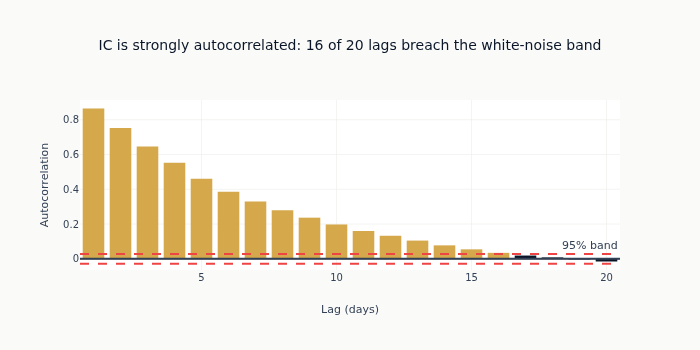


Significant autocorrelation lags: 16/20

This means naive t-statistics will overstate significance!


In [5]:
# Compute autocorrelation function
def compute_acf(series, nlags=20):
    """Compute autocorrelation function."""
    n = len(series)
    series = series - np.mean(series)
    acf = []
    for lag in range(nlags + 1):
        if lag == 0:
            acf.append(1.0)
        else:
            acf.append(np.corrcoef(series[lag:], series[:-lag])[0, 1])
    return np.array(acf)


acf_values = compute_acf(ic_series, nlags=20)

# Significance bounds for white noise
n = len(ic_series)
sig_bound = 1.96 / np.sqrt(n)

# Visualize ACF
fig = go.Figure()

# Count significant lags
n_significant_lags = sum(abs(acf_values[1:]) > sig_bound)

fig.add_trace(
    go.Bar(
        x=list(range(1, 21)),
        y=acf_values[1:],
        name="ACF",
        marker_color=[
            COLORS["amber"] if abs(v) > sig_bound else COLORS["blue"] for v in acf_values[1:]
        ],
    )
)

fig.add_hline(
    y=sig_bound, line_dash="dash", line_color=COLORS["negative"], annotation_text="95% band"
)
fig.add_hline(y=-sig_bound, line_dash="dash", line_color=COLORS["negative"])
fig.add_hline(y=0, line_color=COLORS["neutral"])

fig.update_layout(
    title=f"IC is strongly autocorrelated: {n_significant_lags} of 20 lags breach the "
    "white-noise band",
    xaxis_title="Lag (days)",
    yaxis_title="Autocorrelation",
    template="ml4t",
    height=350,
)
fig.show()
print(f"\nSignificant autocorrelation lags: {n_significant_lags}/20")
print("\nThis means naive t-statistics will overstate significance!")

### 1.1 Library Autocorrelation Analysis

The library version includes PACF and the **Ljung-Box portmanteau test**,
which tests the joint null that all autocorrelations up to lag $L$ are zero.

In [6]:
acf_analysis = analyze_autocorrelation(ic_series, max_lags=20, alpha=0.05)

print("=== ml4t-diagnostic Autocorrelation Analysis ===\n")
print(f"Significant ACF lags:  {acf_analysis.significant_acf_lags}")
print(f"Significant PACF lags: {acf_analysis.significant_pacf_lags}")
print(f"Is white noise:        {acf_analysis.is_white_noise}")
print(f"Suggested ARIMA order: {acf_analysis.suggested_arima_order}")

=== ml4t-diagnostic Autocorrelation Analysis ===

Significant ACF lags:  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Significant PACF lags: [1, 3, 5, 7]
Is white noise:        False
Suggested ARIMA order: (1, 0, 14)


## 2. HAC (Newey-West) Adjustment

HAC (Heteroskedasticity and Autocorrelation Consistent) standard errors account
for serial correlation in the IC series.

The Newey-West estimator uses a weighted sum of autocovariances:

$$\hat{\sigma}^2_{HAC} = \hat{\gamma}_0 + 2\sum_{j=1}^{L} w_j \hat{\gamma}_j$$

Where $w_j = 1 - j/(L+1)$ (Bartlett kernel) and $L$ is the lag truncation.

In [7]:
# Compute HAC-adjusted statistics
hac_result = compute_ic_hac_stats(ic_series)

# Compare naive vs HAC
naive_se = np.std(ic_series, ddof=1) / np.sqrt(len(ic_series))
naive_t = np.mean(ic_series) / naive_se

print("=== Naive vs HAC Inference ===\n")
print(f"Mean IC: {hac_result['mean_ic']:.4f}")
print("\nStandard Errors:")
print(f"  Naive SE:    {naive_se:.4f}")
print(f"  HAC SE:      {hac_result['hac_se']:.4f}")
print(f"  Inflation:   {hac_result['hac_se'] / naive_se:.2f}x")

print("\nt-Statistics:")
print(f"  Naive t:     {naive_t:.2f}")
print(f"  HAC t:       {hac_result['t_stat']:.2f}")

print("\np-Values:")
print(f"  Naive p:     {2 * (1 - stats.t.cdf(abs(naive_t), len(ic_series) - 1)):.4f}")
print(f"  HAC p:       {hac_result['p_value']:.4f}")

# Significance conclusion
alpha = 0.05
naive_sig = "Yes" if abs(naive_t) > stats.t.ppf(1 - alpha / 2, len(ic_series) - 1) else "No"
hac_sig = "Yes" if hac_result["p_value"] < alpha else "No"

print("\nSignificant at α=0.05?")
print(f"  Naive:       {naive_sig}")
print(f"  HAC:         {hac_sig}")

if naive_sig == "Yes" and hac_sig == "No":
    print("\n  WARNING: Naive test finds significance that HAC adjustment removes!")

=== Naive vs HAC Inference ===

Mean IC: 0.0008

Standard Errors:
  Naive SE:    0.0044
  HAC SE:      0.0112
  Inflation:   2.54x

t-Statistics:
  Naive t:     0.19
  HAC t:       0.07

p-Values:
  Naive p:     0.8524
  HAC p:       0.9416

Significant at α=0.05?
  Naive:       No
  HAC:         No


### Effective Sample Size

The HAC SE inflation factor tells us how much the autocorrelation reduces our
effective sample size:

$$T_{eff} = T \times \left(\frac{\sigma_{naive}}{\sigma_{HAC}}\right)^2$$

In [8]:
# Compute effective sample size
inflation_factor = hac_result["hac_se"] / naive_se
effective_n = len(ic_series) / (inflation_factor**2)

print("=== Effective Sample Size ===\n")
print(f"Actual observations: {len(ic_series)}")
print(f"HAC inflation factor: {inflation_factor:.2f}x")
print(f"Effective sample size: {effective_n:.0f}")
print(f"Efficiency loss: {(1 - effective_n / len(ic_series)) * 100:.0f}%")

=== Effective Sample Size ===

Actual observations: 4989
HAC inflation factor: 2.54x
Effective sample size: 773
Efficiency loss: 85%


## 3. Block Bootstrap for Robust CI

When IC series has autocorrelation, **iid bootstrap is invalid**. We use
**block bootstrap** which preserves the dependence structure by resampling
contiguous blocks of observations.

Two common approaches:
1. **Moving Block Bootstrap (MBB)**: Fixed block length
2. **Stationary Bootstrap**: Random block lengths (geometric distribution)

We use the `arch` library's `StationaryBootstrap` for robust inference.

In [9]:
# Block bootstrap implementation
def block_bootstrap_ic_ci(
    ic_series: np.ndarray,
    n_bootstrap: int = 1000,
    block_length: int = 21,
    alpha: float = 0.05,
    random_state: int = 42,
) -> dict:
    """
    Compute block bootstrap confidence interval for mean IC.

    Uses the Politis-Romano stationary bootstrap from `arch.bootstrap`:
    random block lengths drawn from a geometric distribution with
    expected length equal to ``block_length``.

    Parameters
    ----------
    ic_series : array
        Time series of IC values
    n_bootstrap : int
        Number of bootstrap replications
    block_length : int
        Expected block length (mean of the geometric distribution)
    alpha : float
        Significance level (default 0.05 for 95% CI)
    random_state : int
        Random seed for reproducibility

    Returns
    -------
    dict with mean, CI bounds, and bootstrap distribution
    """
    ic_series = np.array(ic_series)

    bs = StationaryBootstrap(block_length, ic_series, seed=random_state)
    bootstrap_means = np.array([np.mean(data[0][0]) for data in bs.bootstrap(n_bootstrap)])

    # Percentile confidence interval
    ci_lower = np.percentile(bootstrap_means, 100 * alpha / 2)
    ci_upper = np.percentile(bootstrap_means, 100 * (1 - alpha / 2))

    return {
        "mean": np.mean(ic_series),
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "bootstrap_std": np.std(bootstrap_means),
        "bootstrap_means": bootstrap_means,
        "method": "Stationary Bootstrap",
        "block_length": block_length,
    }

In [10]:
# Run block bootstrap
n_boot = N_BOOT
block_result = block_bootstrap_ic_ci(
    ic_series, n_bootstrap=n_boot, block_length=21, random_state=SEED
)

# Compare with HAC CI
hac_ci_lower = hac_result["mean_ic"] - 1.96 * hac_result["hac_se"]
hac_ci_upper = hac_result["mean_ic"] + 1.96 * hac_result["hac_se"]

print("=== Block Bootstrap vs HAC Confidence Intervals ===\n")
print(f"Method: {block_result['method']} (block length={block_result['block_length']})")
print(f"Bootstrap replications: {n_boot}")
print(f"\nMean IC: {block_result['mean']:.4f}")
print("\n95% Confidence Intervals:")
print(f"  Block Bootstrap: [{block_result['ci_lower']:.4f}, {block_result['ci_upper']:.4f}]")
print(f"  HAC (Newey-West): [{hac_ci_lower:.4f}, {hac_ci_upper:.4f}]")
print("\nStandard Errors:")
print(f"  Block Bootstrap: {block_result['bootstrap_std']:.4f}")
print(f"  HAC:             {hac_result['hac_se']:.4f}")

# Does CI include zero?
ci_includes_zero = block_result["ci_lower"] <= 0 <= block_result["ci_upper"]
print(f"\nBlock Bootstrap CI includes zero: {'Yes' if ci_includes_zero else 'No'}")

=== Block Bootstrap vs HAC Confidence Intervals ===

Method: Stationary Bootstrap (block length=21)
Bootstrap replications: 2000

Mean IC: 0.0008

95% Confidence Intervals:
  Block Bootstrap: [-0.0253, 0.0271]
  HAC (Newey-West): [-0.0212, 0.0228]

Standard Errors:
  Block Bootstrap: 0.0132
  HAC:             0.0112

Block Bootstrap CI includes zero: Yes


### 3.1 Library vs Manual Bootstrap: When to Use Each

The `ml4t-diagnostic` library provides `stationary_bootstrap_ic()` for
**cross-sectional** bootstrap: given arrays of predictions and returns for a
single date, it resamples asset pairs and recomputes Spearman IC. This is useful
when you want a confidence interval for a single cross-section's IC.

For **time-series** inference on the IC series itself — "is the mean IC over
many dates significantly different from zero?" — the correct tool is the
block bootstrap from Section 3 above, which preserves temporal dependence.

```python
# Cross-sectional bootstrap (library) — CI for one date's IC
from ml4t.diagnostic.evaluation.stats.hac_standard_errors import stationary_bootstrap_ic
result = stationary_bootstrap_ic(signals_t, returns_t, n_samples=1000)

# Time-series bootstrap (manual) — CI for mean IC across dates
block_bootstrap_ic_ci(ic_series, n_bootstrap=2000, block_length=21)
```

Throughout this notebook we use the manual block bootstrap because we are
testing whether the *time-averaged* IC is significantly positive.

In [11]:
print("=== Block Bootstrap Summary (recommended for IC time series) ===\n")
print(f"  IC: {block_result['mean']:.4f}")
print(f"  Bootstrap SE: {block_result['bootstrap_std']:.4f}")
print(f"  95% CI: [{block_result['ci_lower']:.4f}, {block_result['ci_upper']:.4f}]")
print(f"  HAC CI: [{hac_ci_lower:.4f}, {hac_ci_upper:.4f}]")

=== Block Bootstrap Summary (recommended for IC time series) ===

  IC: 0.0008
  Bootstrap SE: 0.0132
  95% CI: [-0.0253, 0.0271]
  HAC CI: [-0.0212, 0.0228]


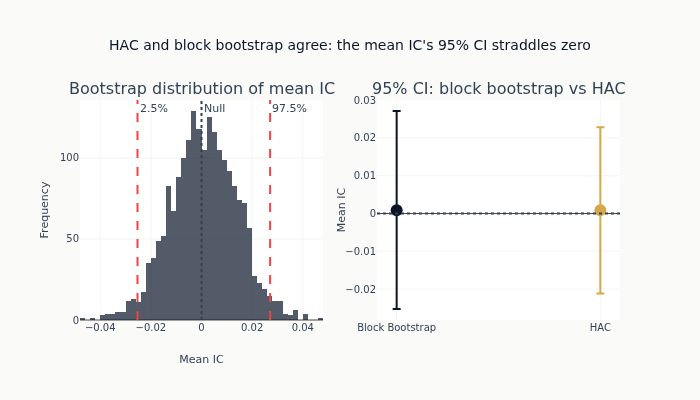

In [12]:
# Visualize bootstrap distribution
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=["Bootstrap distribution of mean IC", "95% CI: block bootstrap vs HAC"],
)

# Bootstrap distribution
fig.add_trace(
    go.Histogram(
        x=block_result["bootstrap_means"],
        nbinsx=50,
        name="Bootstrap means",
        marker_color=COLORS["blue"],
        opacity=0.7,
    ),
    row=1,
    col=1,
)

# Mark CIs
fig.add_vline(
    x=block_result["ci_lower"],
    line_dash="dash",
    line_color=COLORS["negative"],
    annotation_text="2.5%",
    row=1,
    col=1,
)
fig.add_vline(
    x=block_result["ci_upper"],
    line_dash="dash",
    line_color=COLORS["negative"],
    annotation_text="97.5%",
    row=1,
    col=1,
)
fig.add_vline(
    x=0, line_dash="dot", line_color=COLORS["neutral"], annotation_text="Null", row=1, col=1
)

# CI comparison
methods = ["Block Bootstrap", "HAC"]
ci_lowers = [block_result["ci_lower"], hac_ci_lower]
ci_uppers = [block_result["ci_upper"], hac_ci_upper]
means = [block_result["mean"], hac_result["mean_ic"]]

for i, method in enumerate(methods):
    # CI as error bars
    fig.add_trace(
        go.Scatter(
            x=[method],
            y=[means[i]],
            error_y=dict(
                type="data",
                symmetric=False,
                array=[ci_uppers[i] - means[i]],
                arrayminus=[means[i] - ci_lowers[i]],
            ),
            mode="markers",
            marker=dict(size=12, color=[COLORS["blue"], COLORS["amber"]][i]),
            name=method,
        ),
        row=1,
        col=2,
    )

fig.add_hline(y=0, line_dash="dot", line_color=COLORS["neutral"], row=1, col=2)

fig.update_layout(
    title="HAC and block bootstrap agree: the mean IC's 95% CI straddles zero",
    height=400,
    template="ml4t",
    showlegend=False,
)
fig.update_xaxes(title_text="Mean IC", row=1, col=1)
fig.update_yaxes(title_text="Frequency", row=1, col=1)
fig.update_yaxes(title_text="Mean IC", row=1, col=2)

fig.show()

## 4. Practical vs Statistical Significance

Statistical significance of an IC time-series mean is a separate question
from whether the signal is economically tradeable. The table below summarises
typical detectability of a mean IC at the indicated magnitudes; net P&L
after costs is a separate calculation handled in `05_signal_evaluation`
(break-even cost analysis) and the case-study cost models (Ch16-18).

| $\bar{\text{IC}}$ | Statistical detectability on multi-year daily samples |
|----|------------------------------------|
| 0.02 | At the boundary of HAC detectability; requires large $T$ |
| 0.03 | Typically detectable with HAC-adjusted inference |
| 0.05 | Comfortably above the HAC standard error in published equity-factor studies |
| 0.10 | Outside the published cross-sectional range; prior is leakage until ruled out |

Whether any of these magnitudes survives transaction costs depends on
rebalancing frequency, turnover, and capacity — see the break-even
analysis in `05_signal_evaluation`.

In [13]:
# Practical significance analysis
print("=== Practical Significance Analysis ===\n")

observed_ic = np.mean(ic_series)
print(f"Observed IC: {observed_ic:.4f}")
print(f"HAC t-stat: {hac_result['t_stat']:.2f}")
print(f"HAC p-value: {hac_result['p_value']:.4f}")

# Cost-adjusted interpretation
# Simplified model: Net IC ≈ IC - cost_factor × turnover
# Assuming ~50% monthly turnover and 10bps round-trip cost
turnover_assumption = 0.5  # 50% monthly turnover
cost_per_trade = 0.001  # 10bps
cost_impact = turnover_assumption * cost_per_trade * 12  # Annualized

print("\nCost assumptions:")
print(f"  Monthly turnover: {turnover_assumption:.0%}")
print(f"  Round-trip cost: {cost_per_trade * 10000:.0f} bps")
print(f"  Annual cost drag: {cost_impact:.2%}")

# Rough IR approximation: IR ≈ IC × √(252) × some multiplier
# This is a simplified Grinold approximation
ir_approx = observed_ic * np.sqrt(252)
print(f"\nGrinold IR approximation (raw): {ir_approx:.2f}")
print("  (This is a raw, pre-cost upper bound — net IR depends on turnover and costs;")
print("   the break-even cost analysis in `05_signal_evaluation` evaluates feasibility.)")

=== Practical Significance Analysis ===

Observed IC: 0.0008
HAC t-stat: 0.07
HAC p-value: 0.9416

Cost assumptions:
  Monthly turnover: 50%
  Round-trip cost: 10 bps
  Annual cost drag: 0.60%

Grinold IR approximation (raw): 0.01
  (This is a raw, pre-cost upper bound — net IR depends on turnover and costs;
   the break-even cost analysis in `05_signal_evaluation` evaluates feasibility.)


## 5. Track Record Planning

How many observations do we need to be confident in our IC estimate?

Using HAC-adjusted effective sample size:

$$T_{required} = \left(\frac{z_{\alpha/2} \times \sigma_{IC}}{IC_{target}}\right)^2 \times \text{HAC inflation}^2$$

In [14]:
def min_track_record_ic(
    target_ic: float,
    ic_std: float,
    confidence: float = 0.95,
    hac_inflation: float = 1.5,
) -> int:
    """
    Minimum track record to confirm IC with given confidence.

    Uses HAC-adjusted effective sample size.

    Parameters
    ----------
    target_ic : float
        Minimum IC we want to detect
    ic_std : float
        Standard deviation of IC series
    confidence : float
        Required confidence level
    hac_inflation : float
        HAC SE inflation factor (typically 1.5-2.5 for daily IC)

    Returns
    -------
    int : minimum periods needed (actual, not effective)
    """
    z = stats.norm.ppf((1 + confidence) / 2)

    # Base formula without HAC
    base_n = (z * ic_std / target_ic) ** 2

    # Adjust for autocorrelation
    actual_n = base_n * (hac_inflation**2)

    return int(np.ceil(actual_n))

In [15]:
# Track record requirements
ic_std_observed = np.std(ic_series)
hac_inflation = hac_result["hac_se"] / naive_se

print("=== Minimum Track Record for IC Detection ===\n")
print(f"Observed IC std: {ic_std_observed:.4f}")
print(f"HAC inflation factor: {hac_inflation:.2f}x")
print()

target_ics = [0.01, 0.02, 0.03, 0.05]
track_record_rows = []
for target in target_ics:
    min_90 = min_track_record_ic(target, ic_std_observed, 0.90, hac_inflation)
    min_95 = min_track_record_ic(target, ic_std_observed, 0.95, hac_inflation)
    min_99 = min_track_record_ic(target, ic_std_observed, 0.99, hac_inflation)
    track_record_rows.append(
        {
            "target_ic": target,
            "days_90pct": min_90,
            "years_90pct": round(min_90 / 252, 1),
            "days_95pct": min_95,
            "years_95pct": round(min_95 / 252, 1),
            "days_99pct": min_99,
            "years_99pct": round(min_99 / 252, 1),
        }
    )

track_record_df = pl.DataFrame(track_record_rows)
print("Days of cross-sectional IC observations needed at each confidence level:")
display(track_record_df)

=== Minimum Track Record for IC Detection ===

Observed IC std: 0.3119
HAC inflation factor: 2.54x

Days of cross-sectional IC observations needed at each confidence level:


target_ic,days_90pct,years_90pct,days_95pct,years_95pct,days_99pct,years_99pct
f64,i64,f64,i64,f64,i64,f64
0.01,16983,67.4,24113,95.7,41647,165.3
0.02,4246,16.8,6029,23.9,10412,41.3
0.03,1887,7.5,2680,10.6,4628,18.4
0.05,680,2.7,965,3.8,1666,6.6


### Interpretation

The track record requirements are substantial because:

1. **IC is noisy**: Daily cross-sectional IC has high variance
2. **Autocorrelation reduces effective sample**: HAC inflation factor of 1.5-2.5x
3. **Small effects need large samples**: IC of 0.02 is hard to distinguish from 0

**Implication**: Claims of "predictive" factors from 1-2 years of data should be
treated with skepticism, especially if IC is below 0.03.

## 6. IC Inference Report

Export a structured report for downstream use.

In [16]:
# Build IC inference report
inference_report = {
    "signal_name": "momentum_21d",
    "n_observations": len(ic_series),
    "mean_ic": round(float(np.mean(ic_series)), 4),
    "ic_std": round(float(np.std(ic_series)), 4),
    "inference": {
        "naive": {
            "se": round(float(naive_se), 4),
            "t_stat": round(float(naive_t), 2),
            "p_value": round(float(2 * (1 - stats.t.cdf(abs(naive_t), len(ic_series) - 1))), 4),
        },
        "hac": {
            "se": round(float(hac_result["hac_se"]), 4),
            "t_stat": round(float(hac_result["t_stat"]), 2),
            "p_value": round(float(hac_result["p_value"]), 4),
            "inflation_factor": round(float(hac_inflation), 2),
        },
        "block_bootstrap": {
            "method": block_result["method"],
            "block_length": block_result["block_length"],
            "n_replications": n_boot,
            "se": round(float(block_result["bootstrap_std"]), 4),
            "ci_95_lower": round(float(block_result["ci_lower"]), 4),
            "ci_95_upper": round(float(block_result["ci_upper"]), 4),
        },
    },
    "effective_sample_size": round(float(effective_n), 0),
    "ci_includes_zero": bool(ci_includes_zero),
    "autocorrelation_lags_significant": int(n_significant_lags),
}

print("=== IC Inference Report ===\n")
print(json.dumps(inference_report, indent=2))

=== IC Inference Report ===

{
  "signal_name": "momentum_21d",
  "n_observations": 4989,
  "mean_ic": 0.0008,
  "ic_std": 0.3119,
  "inference": {
    "naive": {
      "se": 0.0044,
      "t_stat": 0.19,
      "p_value": 0.8524
    },
    "hac": {
      "se": 0.0112,
      "t_stat": 0.07,
      "p_value": 0.9416,
      "inflation_factor": 2.54
    },
    "block_bootstrap": {
      "method": "Stationary Bootstrap",
      "block_length": 21,
      "n_replications": 2000,
      "se": 0.0132,
      "ci_95_lower": -0.0253,
      "ci_95_upper": 0.0271
    }
  },
  "effective_sample_size": 773.0,
  "ci_includes_zero": true,
  "autocorrelation_lags_significant": 16
}


## Summary

### Key Concepts

| Concept | Description |
|---------|-------------|
| **HAC SE** | Newey-West adjustment for autocorrelated IC |
| **Block Bootstrap** | Preserves dependence structure via block resampling |
| **Effective N** | True sample size after accounting for autocorrelation |
| **Track Record** | Minimum observations to detect a given IC |

### Best Practices

1. **Always use HAC-adjusted t-statistics** - naive t-stats overstate significance
2. **Report block bootstrap CIs** - distribution-free and robust
3. **Consider practical significance** - IC must exceed cost drag
4. **Plan for adequate track records** - 1-2 years rarely sufficient for small IC
5. **Check effective sample size** - may be much smaller than actual observations

### API Reference

```python
from ml4t.diagnostic.metrics import compute_ic_hac_stats

# HAC-adjusted statistics
hac = compute_ic_hac_stats(ic_series)
print(f"HAC t-stat: {hac['t_stat']:.2f}")
print(f"HAC p-value: {hac['p_value']:.4f}")

# Block bootstrap (requires arch library)
from arch.bootstrap import StationaryBootstrap
bs = StationaryBootstrap(21, ic_series)  # 21-day blocks
ci = bs.conf_int(np.mean, 1000, method='percentile')
```

### Next Notebooks

- [`07_multiple_testing`](07_multiple_testing.ipynb) - FDR control when evaluating many factors
- [`08_causal_sanity_checks`](08_causal_sanity_checks.ipynb) - Causal falsification tests